<a href="https://colab.research.google.com/github/Zhukovsky1215/Project539/blob/main/Mr_Beast_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Processing Data

In [ ]:
from kagglehub import KaggleDatasetAdapter
import kagglehub

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "adilshamim8/mrbeast-youtube-comment-sentiment-analysis",
    "sentiment_analysis_dataset.csv",
    pandas_kwargs={'on_bad_lines': 'skip'}
)

df.head()

Using Colab cache for faster access to the 'mrbeast-youtube-comment-sentiment-analysis' dataset.


,Comment,Sentiment
0,Achieving million views in days is dangerous,Positive
1,How many people here want to participate in su...,Neutral
2,Mrbeast is slowly turning into mrjigsaw,Negative
3,genuinely can't believe how dystopian this is,Negative
4,Have of the worlds smartest people compete in ...,Neutral


In [ ]:
# 1. Start with a clean base df, once
base_df = df.dropna(subset=["Comment", "Sentiment"]).copy()
base_df["Comment"] = base_df["Comment"].astype(str).str.strip()
base_df["Sentiment"] = base_df["Sentiment"].astype(str).str.strip()

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    base_df,
    test_size=0.2,
    random_state=42,
    stratify=base_df["Sentiment"],  # or base_df["label"] once encoded
)

print(len(base_df), len(train_df), len(val_df))

6797 5437 1360


# Model 1: RoBERTa-base transformer

In [ ]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd

In [ ]:
# Use a 3-class sentiment model (Negative / Neutral / Positive)
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load config and tokenizer
config = AutoConfig.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Model num_labels:", config.num_labels)
print("Model id2label:", config.id2label)

# ---- Align our Sentiment labels with the model's labels ----
# Model's labels might be like: {0: 'negative', 1: 'neutral', 2: 'positive'}
model_label2id = {label.lower(): idx for idx, label in config.id2label.items()}

# Build mapping from our dataset Sentiment strings to model ids
unique_sents = base_df["Sentiment"].unique()
sent_to_id = {}

for s in unique_sents:
    key = s.strip().lower()
    if key not in model_label2id:
        raise ValueError(
            f"Dataset sentiment '{s}' does not match any model labels {list(model_label2id.keys())}"
        )
    sent_to_id[s] = model_label2id[key]

print("Sentiment → label id mapping:", sent_to_id)

# Add numeric label column to the already-split dataframes
train_df["label"] = train_df["Sentiment"].map(sent_to_id)
val_df["label"]   = val_df["Sentiment"].map(sent_to_id)

# Optional sanity check
print(train_df[["Sentiment", "label"]].head())
print(val_df[["Sentiment", "label"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model num_labels: 3
Model id2label: {0: 'negative', 1: 'neutral', 2: 'positive'}
Sentiment → label id mapping: {'Positive': 2, 'Neutral': 1, 'Negative': 0}
     Sentiment  label
1809   Neutral      1
4806  Positive      2
3560   Neutral      1
6035  Positive      2
4578  Positive      2
     Sentiment  label
522    Neutral      1
2558   Neutral      1
6619  Positive      2
6497  Positive      2
1294  Positive      2


In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

# Wrap the shared train/val data into Hugging Face Datasets
train_ds = Dataset.from_pandas(train_df[["Comment", "label"]].reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df[["Comment", "label"]].reset_index(drop=True))

max_length = 80  # you can tune this later if many comments are longer

def tokenize_fn(batch):
    return tokenizer(
        batch["Comment"],
        truncation=True,
        padding="max_length",  # or use True with DataCollatorWithPadding
        max_length=max_length,
    )

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

# Remove raw text column and set PyTorch format
train_ds = train_ds.remove_columns(["Comment"])
val_ds   = val_ds.remove_columns(["Comment"])

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Data collator (if you want dynamic padding, change padding="max_length" above to padding=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Metrics function for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    prec_macro = precision_score(labels, preds, average="macro", zero_division=0)
    rec_macro = recall_score(labels, preds, average="macro", zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
    }

Map:   0%|          | 0/5437 [00:00<?, ? examples/s]

Map:   0%|          | 0/1360 [00:00<?, ? examples/s]

In [ ]:
# Load the pretrained model (no fine-tuning)
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=config.num_labels,
)

baseline_args = TrainingArguments(
    output_dir="baseline-3class-sentiment",
    per_device_eval_batch_size=32,
    do_train=False,
    do_eval=True,
    logging_steps=50,
    report_to="none",
)

baseline_trainer = Trainer(
    model=baseline_model,
    args=baseline_args,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

baseline_metrics = baseline_trainer.evaluate()
print("==== Baseline: pretrained 3-class sentiment model ====")
for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}")

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/tmp/ipython-input-1071660750.py:16: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  baseline_trainer = Trainer(


==== Baseline: pretrained 3-class sentiment model ====
eval_loss: 0.5581
eval_model_preparation_time: 0.0060
eval_accuracy: 0.7838
eval_f1_macro: 0.5738
eval_precision_macro: 0.5782
eval_recall_macro: 0.7158
eval_runtime: 6.6105
eval_samples_per_second: 205.7320
eval_steps_per_second: 6.5050


In [ ]:
# Reload a fresh copy of the same model for fine-tuning
ft_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=config.num_labels,
)

ft_args = TrainingArguments(
    output_dir="finetuned-3class-sentiment",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=5e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

ft_trainer = Trainer(
    model=ft_model,
    args=ft_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Train
ft_trainer.train()

# Evaluate the fine-tuned model
finetuned_metrics = ft_trainer.evaluate()
print("==== Fine-tuned 3-class sentiment model on MrBeast dataset ====")
for k, v in finetuned_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nBaseline vs Fine-tuned:")
for k in finetuned_metrics:
    if k in baseline_metrics:
        print(f"{k}: baseline={baseline_metrics[k]:.4f}  →  finetuned={finetuned_metrics[k]:.4f}")

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/tmp/ipython-input-1061848773.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  ft_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.144300,0.154133,0.963235,0.887962,0.895930,0.881228
2,0.023600,0.060530,0.991176,0.992902,0.994801,0.991079
3,0.000100,0.061492,0.992647,0.994093,0.995508,0.992721


==== Fine-tuned 3-class sentiment model on MrBeast dataset ====
eval_loss: 0.0615
eval_accuracy: 0.9926
eval_f1_macro: 0.9941
eval_precision_macro: 0.9955
eval_recall_macro: 0.9927
eval_runtime: 4.9229
eval_samples_per_second: 276.2590
eval_steps_per_second: 8.7350
epoch: 3.0000

Baseline vs Fine-tuned:
eval_loss: baseline=0.5581  →  finetuned=0.0615
eval_accuracy: baseline=0.7838  →  finetuned=0.9926
eval_f1_macro: baseline=0.5738  →  finetuned=0.9941
eval_precision_macro: baseline=0.5782  →  finetuned=0.9955
eval_recall_macro: baseline=0.7158  →  finetuned=0.9927
eval_runtime: baseline=6.6105  →  finetuned=4.9229
eval_samples_per_second: baseline=205.7320  →  finetuned=276.2590
eval_steps_per_second: baseline=6.5050  →  finetuned=8.7350


In [ ]:
import torch

id2label = ft_model.config.id2label  # e.g. {0: 'negative', 1: 'neutral', 2: 'positive'}

def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]
    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
    )
    ft_model.eval()
    with torch.no_grad():
        # Move input tensors to the same device as the model
        encodings = {k: v.to(ft_model.device) for k, v in encodings.items()}
        outputs = ft_model(**encodings)
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()

    labels = [id2label[int(p)] for p in preds]
    return list(zip(texts, labels))

# Example:
examples = [
    "This video was amazing, I loved it!",
    "It's okay, not his best work.",
    "I really didn't like this at all.",
]

for text, label in predict_sentiment(examples):
    print(f"{label.upper():8} | {text}")

POSITIVE | This video was amazing, I loved it!
POSITIVE | It's okay, not his best work.
NEGATIVE | I really didn't like this at all.


# Model 2: Embedding + 1D CNN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

import torch
from torch import nn
from torch.utils.data import DataLoader

from datasets import Dataset
from transformers import AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
train_df_cnn = train_df.copy()
val_df_cnn   = val_df.copy()

# Clean text just to be safe
train_df_cnn["Comment"]   = train_df_cnn["Comment"].astype(str).str.strip()
val_df_cnn["Comment"]     = val_df_cnn["Comment"].astype(str).str.strip()
train_df_cnn["Sentiment"] = train_df_cnn["Sentiment"].astype(str).str.strip()
val_df_cnn["Sentiment"]   = val_df_cnn["Sentiment"].astype(str).str.strip()

# Encode labels for CNN
le = LabelEncoder()
le.fit(train_df_cnn["Sentiment"])   # fit on train only

train_df_cnn["label"] = le.transform(train_df_cnn["Sentiment"])
val_df_cnn["label"]   = le.transform(val_df_cnn["Sentiment"])

num_classes = len(le.classes_)
print("Classes:", le.classes_)
print("num_classes:", num_classes)
print("Train size (CNN):", len(train_df_cnn))
print("Val size (CNN):", len(val_df_cnn))

Classes: ['Negative' 'Neutral' 'Positive']
num_classes: 3
Train size (CNN): 5437
Val size (CNN): 1360


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"  # just for tokenizer/vocab
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_length = 80  # similar to before

def tokenize_fn(batch):
    return tokenizer(
        batch["Comment"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )

# Use the CNN-specific dataframes that share the same split
train_ds = Dataset.from_pandas(train_df_cnn[["Comment", "label"]])
val_ds   = Dataset.from_pandas(val_df_cnn[["Comment", "label"]])

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

# Keep only the columns we need and set PyTorch format
train_ds.set_format(
    type="torch",
    columns=["input_ids", "label"],
)
val_ds.set_format(
    type="torch",
    columns=["input_ids", "label"],
)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

Map:   0%|          | 0/5437 [00:00<?, ? examples/s]

Map:   0%|          | 0/1360 [00:00<?, ? examples/s]

In [ ]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, kernel_sizes=(3,4,5), num_filters=64, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids):
        # input_ids: (batch, seq_len)
        x = self.embedding(input_ids)             # (batch, seq_len, embed_dim)
        x = x.transpose(1, 2)                     # (batch, embed_dim, seq_len)

        conv_outs = []
        for conv in self.convs:
            c = conv(x)                           # (batch, num_filters, seq_len-k+1)
            c = torch.relu(c)
            c = torch.max(c, dim=2).values        # global max pool -> (batch, num_filters)
            conv_outs.append(c)

        x = torch.cat(conv_outs, dim=1)           # (batch, num_filters * len(kernel_sizes))
        x = self.dropout(x)
        logits = self.fc(x)                       # (batch, num_classes)
        return logits

vocab_size = tokenizer.vocab_size
embed_dim = 128
kernel_sizes = (3,4,5)
num_filters = 64
dropout = 0.5

model = TextCNN(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_classes=num_classes,
    kernel_sizes=kernel_sizes,
    num_filters=num_filters,
    dropout=dropout
).to(device)

print(model)

TextCNN(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 64, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 64, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 64, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=192, out_features=3, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 8
best_val_f1 = 0.0

for epoch in range(1, epochs + 1):
    # ----- Train -----
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

    avg_train_loss = total_loss / len(train_ds)

    # ----- Evaluate -----
    model.eval()
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids)
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    rec  = recall_score(all_labels, all_preds, average="macro")

    print(f"Epoch {epoch}: train_loss={avg_train_loss:.4f} | "
          f"val_acc={acc:.4f}, val_f1_macro={f1:.4f}")

    # Simple "best model" tracking
    if f1 > best_val_f1:
        best_val_f1 = f1
        torch.save(model.state_dict(), "textcnn_best.pt")
        print("  -> New best model saved.")

Epoch 1: train_loss=0.4513 | val_acc=0.9243, val_f1_macro=0.6824
  -> New best model saved.
Epoch 2: train_loss=0.1574 | val_acc=0.9647, val_f1_macro=0.9493
  -> New best model saved.
Epoch 3: train_loss=0.0788 | val_acc=0.9809, val_f1_macro=0.9845
  -> New best model saved.
Epoch 4: train_loss=0.0450 | val_acc=0.9831, val_f1_macro=0.9863
  -> New best model saved.
Epoch 5: train_loss=0.0280 | val_acc=0.9824, val_f1_macro=0.9857
Epoch 6: train_loss=0.0198 | val_acc=0.9824, val_f1_macro=0.9857
Epoch 7: train_loss=0.0171 | val_acc=0.9809, val_f1_macro=0.9846
Epoch 8: train_loss=0.0161 | val_acc=0.9831, val_f1_macro=0.9863


In [ ]:
# Load best state (optional, if you saved it)
model.load_state_dict(torch.load("textcnn_best.pt", map_location=device))

model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids)
        preds = torch.argmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average="macro")
prec = precision_score(all_labels, all_preds, average="macro")
rec  = recall_score(all_labels, all_preds, average="macro")

print("Multi-kernel TextCNN (PyTorch)")
print(f"Val accuracy:        {acc:.4f}")
print(f"Val F1_macro:        {f1:.4f}")
print(f"Val precision_macro: {prec:.4f}")
print(f"Val recall_macro:    {rec:.4f}")

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Multi-kernel TextCNN (PyTorch)
Val accuracy:        0.9831
Val F1_macro:        0.9863
Val precision_macro: 0.9899
Val recall_macro:    0.9830

Classification report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        16
     Neutral       0.99      0.95      0.97       406
    Positive       0.98      1.00      0.99       938

    accuracy                           0.98      1360
   macro avg       0.99      0.98      0.99      1360
weighted avg       0.98      0.98      0.98      1360



# Model 3: Embedding + MLP

In [ ]:
print("Classes:", le.classes_)
print("num_classes:", num_classes)
print("Vocab size:", tokenizer.vocab_size)

vocab_size = tokenizer.vocab_size

# Hyperparameters specific to the MLP
mlp_embed_dim = 128          # embedding size
mlp_hidden_dims = (128, 64)  # two-layer MLP: 128 -> 64 -> num_classes
mlp_dropout = 0.5
mlp_learning_rate = 1e-3
mlp_epochs = 8

Classes: ['Negative' 'Neutral' 'Positive']
num_classes: 3
Vocab size: 30522


In [ ]:
class TextMLP(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        num_classes,
        pad_token_id,
        hidden_dims=(128, 64),
        dropout=0.5,
    ):
        super().__init__()

        # Token embedding as in the CNN model
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_token_id
        )

        # Build MLP layers: [embed_dim] -> hidden_dims... -> num_classes
        layers = []
        in_dim = embed_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h

        layers.append(nn.Linear(in_dim, num_classes))
        self.mlp = nn.Sequential(*layers)

    def forward(self, input_ids):
        """
        input_ids: (batch, seq_len)
        We reuse the same train_loader/val_loader format as TextCNN:
        batch["input_ids"], batch["label"]
        """
        # (batch, seq_len, embed_dim)
        x = self.embedding(input_ids)

        # Simple average pooling over the sequence dimension
        # (we rely on pad_token_id having its own embedding; this is fine as a baseline)
        pooled = x.mean(dim=1)   # (batch, embed_dim)

        logits = self.mlp(pooled)  # (batch, num_classes)
        return logits

In [ ]:
mlp_model = TextMLP(
    vocab_size=vocab_size,
    embed_dim=mlp_embed_dim,
    num_classes=num_classes,
    pad_token_id=tokenizer.pad_token_id,
    hidden_dims=mlp_hidden_dims,
    dropout=mlp_dropout,
).to(device)

mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=mlp_learning_rate)

print(mlp_model)

TextMLP(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [ ]:
# Training loop for the MLP model

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

mlp_best_val_f1 = 0.0

for epoch in range(1, mlp_epochs + 1):
    # ----- Train -----
    mlp_model.train()
    total_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        mlp_optimizer.zero_grad()
        logits = mlp_model(input_ids)
        loss = mlp_criterion(logits, labels)
        loss.backward()
        mlp_optimizer.step()

        total_loss += loss.item() * input_ids.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)

    # ----- Validation -----
    mlp_model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            logits = mlp_model(input_ids)
            preds = torch.argmax(logits, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    rec  = recall_score(all_labels, all_preds, average="macro")

    print(
        f"Epoch {epoch}: "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_acc={acc:.4f}, val_f1_macro={f1:.4f}"
    )

    # Track and save the best MLP model based on F1
    if f1 > mlp_best_val_f1:
        mlp_best_val_f1 = f1
        torch.save(mlp_model.state_dict(), "textmlp_best.pt")
        print("  -> New best MLP model saved.")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1: train_loss=0.7248 | val_acc=0.6897, val_f1_macro=0.2721
  -> New best MLP model saved.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 2: train_loss=0.4900 | val_acc=0.8735, val_f1_macro=0.5667
  -> New best MLP model saved.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 3: train_loss=0.2870 | val_acc=0.9125, val_f1_macro=0.6018
  -> New best MLP model saved.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 4: train_loss=0.1891 | val_acc=0.9338, val_f1_macro=0.6169
  -> New best MLP model saved.
Epoch 5: train_loss=0.1329 | val_acc=0.9434, val_f1_macro=0.6983
  -> New best MLP model saved.
Epoch 6: train_loss=0.0952 | val_acc=0.9618, val_f1_macro=0.7715
  -> New best MLP model saved.
Epoch 7: train_loss=0.0707 | val_acc=0.9669, val_f1_macro=0.8975
  -> New best MLP model saved.
Epoch 8: train_loss=0.0530 | val_acc=0.9728, val_f1_macro=0.9674
  -> New best MLP model saved.


In [ ]:
# Final evaluation for the MLP model

from sklearn.metrics import classification_report

# Reload best weights (if training cell saved them)
mlp_best = TextMLP(
    vocab_size=vocab_size,
    embed_dim=mlp_embed_dim,
    num_classes=num_classes,
    pad_token_id=tokenizer.pad_token_id,
    hidden_dims=mlp_hidden_dims,
    dropout=mlp_dropout,
).to(device)

mlp_best.load_state_dict(torch.load("textmlp_best.pt", map_location=device))
mlp_best.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        logits = mlp_best(input_ids)
        preds = torch.argmax(logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

acc  = accuracy_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds, average="macro")
prec = precision_score(all_labels, all_preds, average="macro")
rec  = recall_score(all_labels, all_preds, average="macro")

print("Embedding + MLP (PyTorch)")
print(f"Val accuracy:        {acc:.4f}")
print(f"Val F1_macro:        {f1:.4f}")
print(f"Val precision_macro: {prec:.4f}")
print(f"Val recall_macro:    {rec:.4f}")

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Embedding + MLP (PyTorch)
Val accuracy:        0.9728
Val F1_macro:        0.9674
Val precision_macro: 0.9815
Val recall_macro:    0.9543

Classification report:
              precision    recall  f1-score   support

    Negative       1.00      0.94      0.97        16
     Neutral       0.97      0.94      0.95       406
    Positive       0.97      0.99      0.98       938

    accuracy                           0.97      1360
   macro avg       0.98      0.95      0.97      1360
weighted avg       0.97      0.97      0.97      1360



# Model comparison: RoBERTa vs TextCNN vs MLP

In [ ]:
import pandas as pd

results = pd.DataFrame([
    {
        "model": "Model 1 – RoBERTa (HF)",
        "val_accuracy": 0.9926,   # <-- put RoBERTa val accuracy here
        "val_f1_macro": 0.9941,   # <-- put RoBERTa macro-F1 here
    },
    {
        "model": "Model 2 – TextCNN (PyTorch)",
        "val_accuracy": 0.9831,   # <-- put TextCNN val accuracy here
        "val_f1_macro": 0.9863,   # <-- put TextCNN macro-F1 here
    },
    {
        "model": "Model 3 – Embedding + MLP (PyTorch)",
        "val_accuracy": 0.9728,   # <-- put MLP val accuracy here
        "val_f1_macro": 0.9674,   # <-- put MLP macro-F1 here
    },
])

results.sort_values("val_f1_macro", ascending=False).reset_index(drop=True)

,model,val_accuracy,val_f1_macro
0,Model 1 – RoBERTa (HF),0.9926,0.9941
1,Model 2 – TextCNN (PyTorch),0.9831,0.9863
2,Model 3 – Embedding + MLP (PyTorch),0.9728,0.9674


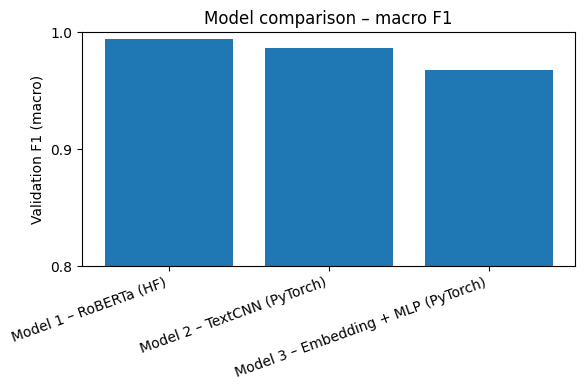

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.bar(results["model"], results["val_f1_macro"])
plt.xticks(rotation=20, ha="right")

plt.ylabel("Validation F1 (macro)")
plt.title("Model comparison – macro F1")

# Make differences look smaller / less obvious
plt.ylim(0.8, 1)              # full 0–1 range, no zoom-in
plt.yticks([0.8, 0.9, 1.0])   # coarse ticks so small gaps are less visible

plt.tight_layout()
plt.show()